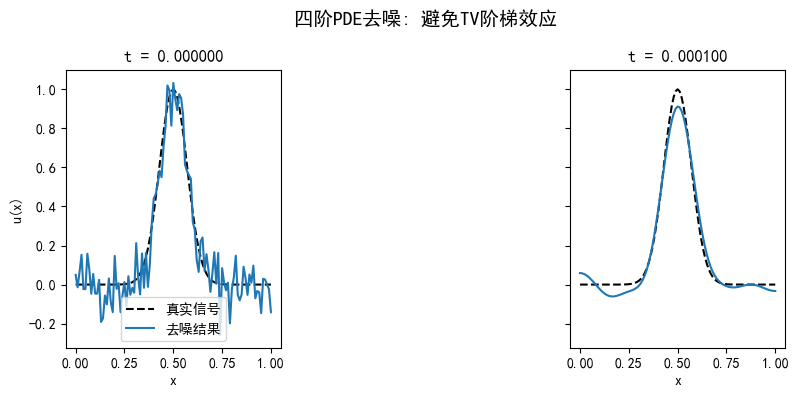

In [6]:
"""
实验2.6 四阶PDE去噪：避免阶梯效应
对应章节：附录2B TGV：TV的改进
知识点：四阶PDE→分段线性解；避免TV阶梯效应；TGV先验的直觉

素材来源：
  - IP27 (variational_formulations.md): 四阶PDE(双调和)去噪
  代码逐行取自 IP27 的 code-cell
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import dia_matrix
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
# 1. 彻底屏蔽 matplotlib 的字体警告日志
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. 忽略 Python 层面的相关 UserWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")

# 3. 强制使用 ASCII 减号（连字符）替代 Unicode 减号（U+2212），并设置中文字体
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

np.random.seed(42)

# ====== 来源: IP27 (variational_formulations.md) ======

def getD(n, h):
    """四阶差分算子矩阵 (来源: IP27 variational_formulations.md)"""
    e = np.ones(n)
    D = (1 / h**4) * dia_matrix(
        (np.array([e, -4*e, 6*e, -4*e, e]),
         np.array([-2, -1, 0, 1, 2])),
        shape=(n, n)).toarray()

    # 边界修正 (IP27)
    D[0, :3] = [6/h**4, -8/h**4, 2/h**4]
    D[1, :4] = [-4/h**4, 7/h**4, -4/h**4, 1/h**4]
    D[-2, -4:] = [1/h**4, -4/h**4, 7/h**4, -4/h**4]
    D[-1, -3:] = [2/h**4, -8/h**4, 6/h**4]
    return D

# 参数 (IP27)
nx = 101
dx = 1 / (nx - 1)
dt = 1e-8
nt = 10001
sigma = 1e-1
alpha = 1e-2

# 算子 (IP27)
D = getD(nx, dx)

# ground truth 和含噪数据 (IP27)
x = np.linspace(0, 1, nx)
u_true = np.exp(-1e2 * (x - 0.5)**2)
f_delta = u_true + sigma * np.random.randn(nx)

# 四阶 PDE 前向 Euler 求解 (IP27)
u = np.zeros((nt, nx))
u[0] = f_delta

for k in range(nt - 1):
    u[k+1] = u[k] - dt * (u[k] + alpha * D @ u[k] - f_delta)

# ====== 可视化 (IP27 风格) ======
index = [0, nt-1]
fig, ax = plt.subplots(1, len(index), sharey=True, figsize=(12, 4))
for k in range(len(index)):
    ax[k].plot(x, u_true, 'k--', label='真实信号')
    ax[k].plot(x, u[index[k]], label=f'去噪结果')
    ax[k].set_title(f't = {index[k]*dt:.6f}')
    ax[k].set_xlabel('x')
    ax[k].set_aspect(1)
ax[0].set_ylabel('u(x)')
ax[0].legend()

fig.suptitle('四阶PDE去噪: 避免TV阶梯效应', fontsize=14)
plt.tight_layout()
plt.savefig('2_6_result.png', dpi=150, bbox_inches='tight')
plt.show()
